**1.IMPORT LIBRARY**

In [1]:
import pandas as pd
from fastapi import requests
import requests
import holidays 
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import ttest_ind
import joblib
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



**2.DATA IMPORT**

In [2]:
df = pd.read_csv('final_synthetic_90days_10flights.csv')
pd.set_option('display.max_columns', None)
df

,Flight Date,Airline Code,Airline Name,Flight Number,AC Reg,Aircraft Type,ULD Number,MAWB Prefix,MAWB Number,Master Sequence,HAWB Prefix,HAWB Number,House Sequence,Pieces,Weight,SHC,Nature of Goods,Origin-Destination,Transfer Flight,Transfer Flight Date,Status - Departed,Consignee Name
0,01-05-2026,EK,EMIRATES AIRLINE,801,A6-EOO,NaN,ULD000,176,176-45788921,20086850,NaN,NaN,NaN,82,1136.2,RFL,GENERAL GOODS,AMS-JED,NaN,NaN,1,BINZAGR UNILEVER LIMITED CO
1,01-05-2026,EK,EMIRATES AIRLINE,801,A6-EOO,NaN,ULD001,176,176-41632483,20086023,NaN,NaN,NaN,66,558.7,EAW,GENERAL GOODS,MAA-JED,NaN,NaN,1,BINZAGR UNILEVER LIMITED CO
2,01-05-2026,EK,EMIRATES AIRLINE,801,A6-EOO,NaN,ULD002,176,176-86893497,20076396,NaN,NaN,NaN,58,548.4,RFL,GENERAL GOODS,OSL-JED,NaN,NaN,1,LANDMARK ARABIA CO LTD
3,01-05-2026,EK,EMIRATES AIRLINE,801,A6-EOO,NaN,ULD003,176,176-72250665,20088431,NaN,NaN,NaN,83,857.4,COL,GENERAL GOODS,MAA-JED,NaN,NaN,1,SAUDIA AEROSPACE ENGINEERING
4,01-05-2026,EK,EMIRATES AIRLINE,801,A6-EOO,NaN,ULD004,176,176-71306900,20084502,NaN,NaN,NaN,73,856.6,RFL,GENERAL GOODS,FRA-JED,NaN,NaN,1,LULU SAUDI HYPERMARKETS LLC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,29-07-2026,BA,BRITISH AIRWAYS,105,G-XLEA,NaN,ULD8995,176,176-79866424,20089955,NaN,NaN,NaN,51,691.1,HEA,GENERAL GOODS,AMS-JED,NaN,NaN,1,LANDMARK ARABIA CO LTD
8996,29-07-2026,BA,BRITISH AIRWAYS,105,G-XLEA,NaN,ULD8996,176,176-60321364,20087161,NaN,NaN,NaN,69,1056.8,ECC,GENERAL GOODS,AMS-JED,NaN,NaN,1,BINZAGR UNILEVER LIMITED CO
8997,29-07-2026,BA,BRITISH AIRWAYS,105,G-XLEA,NaN,ULD8997,176,176-37429195,20079117,NaN,NaN,NaN,45,598.1,EAW,GENERAL GOODS,OSL-JED,NaN,NaN,1,SAMSUNG EA SAUDI ARABIA
8998,29-07-2026,BA,BRITISH AIRWAYS,105,G-XLEA,NaN,ULD8998,176,176-65593029,20079990,NaN,NaN,NaN,68,654.4,AOG,GENERAL GOODS,MAA-JED,NaN,NaN,1,MUSASAT BASAMAT MASAKA EST


In [3]:
df['SHC'].unique()

array(['RFL', 'EAW', 'COL', 'ECC', 'HEA', 'AOG', 'SPX', 'ELM'],
      dtype=object)

In [4]:
df['Flight Date'] = pd.to_datetime(
    df['Flight Date'],
    format='%d-%m-%Y'
)

df = df[~(
    (df['Flight Date'].dt.month == 6) &
    (df['Flight Date'].dt.day > 28)
)]

month_map = {
    5:1,   # May → Jan
    6:2,   # June → Feb
    7:3    # July → Mar
}

df['Flight Date'] = df['Flight Date'].apply(
    lambda x: x.replace(
        year=2026,
        month=month_map.get(x.month, x.month)
    )
)

C:\Users\BalajiChitrarasu\AppData\Local\Temp\ipykernel_31680\2982906640.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Flight Date'] = df['Flight Date'].apply(


In [5]:
df = df.dropna(axis=1, how='all')

In [6]:
df[['origin','destination']] = df['Origin-Destination'].str.split('-', expand=True)
airports = pd.unique(
df[['origin','destination']].values.ravel()
)

In [7]:
print(f"Unique destinations: {df['destination'].unique()}")
print(f"Unique origins: {df['origin'].unique()}")

Unique destinations: ['JED']
Unique origins: ['AMS' 'MAA' 'OSL' 'FRA' 'MXP' 'PVG' 'JFK' 'HAM' 'DXB']


In [8]:
df = df.drop(columns=['Origin-Destination'])
df = df[df['ULD Number'] != 'ULD000'].copy()


In [9]:
df

,Flight Date,Airline Code,Airline Name,Flight Number,AC Reg,ULD Number,MAWB Prefix,MAWB Number,Master Sequence,Pieces,Weight,SHC,Nature of Goods,Status - Departed,Consignee Name,origin,destination
1,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD001,176,176-41632483,20086023,66,558.7,EAW,GENERAL GOODS,1,BINZAGR UNILEVER LIMITED CO,MAA,JED
2,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD002,176,176-86893497,20076396,58,548.4,RFL,GENERAL GOODS,1,LANDMARK ARABIA CO LTD,OSL,JED
3,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD003,176,176-72250665,20088431,83,857.4,COL,GENERAL GOODS,1,SAUDIA AEROSPACE ENGINEERING,MAA,JED
4,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD004,176,176-71306900,20084502,73,856.6,RFL,GENERAL GOODS,1,LULU SAUDI HYPERMARKETS LLC,FRA,JED
5,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD005,176,176-54738553,20081016,69,1075.8,ECC,GENERAL GOODS,1,SAUDI ROYAL FLEET,MXP,JED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8995,176,176-79866424,20089955,51,691.1,HEA,GENERAL GOODS,1,LANDMARK ARABIA CO LTD,AMS,JED
8996,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8996,176,176-60321364,20087161,69,1056.8,ECC,GENERAL GOODS,1,BINZAGR UNILEVER LIMITED CO,AMS,JED
8997,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8997,176,176-37429195,20079117,45,598.1,EAW,GENERAL GOODS,1,SAMSUNG EA SAUDI ARABIA,OSL,JED
8998,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8998,176,176-65593029,20079990,68,654.4,AOG,GENERAL GOODS,1,MUSASAT BASAMAT MASAKA EST,MAA,JED


**3. WEATHER DATA CREATION**


In [10]:
origins = df['origin'].unique()
print(origins)

['MAA' 'OSL' 'FRA' 'MXP' 'PVG' 'JFK' 'HAM' 'AMS' 'DXB']


In [11]:
destinations = df['destination'].unique()
print(destinations)

['JED']


In [12]:
origins_coords = {
'AMS': (52.3676,4.9041),
'MAA': (13.0827,80.2707),
'OSL': (59.9139,10.7522),
'FRA': (50.1109,8.6821),
'MXP': (45.6306,8.7281),
'PVG': (31.1443,121.8083),
'JFK': (40.6413,-73.7781),
'HAM': (53.5511,9.9937),
'DXB': (25.2532,55.3657),
}

destinations_coords = {'JED': (21.5433,39.1728)}

**3.1 weather data for origin airports**

In [13]:
import pandas as pd
import requests

origin_weather_list = []

start_date = "2026-01-01"
end_date = "2026-03-31"

# unique origin airports
origin_airports = df['origin'].unique()

for airport in origin_airports:

    lat, lon = origins_coords[airport]

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": (
            "temperature_2m_mean,"
            "precipitation_sum,"
            "windspeed_10m_max,"
            "snowfall_sum"
        ),
        "timezone": "auto"
    }

    r = requests.get(url, params=params)
    data = r.json()

    origin_weather = pd.DataFrame({
        "origin": airport,
        "Flight Date": pd.to_datetime(data["daily"]["time"]),
        "origin_temp": data["daily"]["temperature_2m_mean"],
        "origin_rain": data["daily"]["precipitation_sum"],
        "origin_wind_speed": data["daily"]["windspeed_10m_max"],
        "origin_snowfall": data["daily"]["snowfall_sum"]
    })

    origin_weather_list.append(origin_weather)

origin_weather_df = pd.concat(origin_weather_list, ignore_index=True)

**3.2 weather data for destination airports**

In [14]:
destination_weather_list = []

# unique destination airports
destination_airports = df['destination'].unique()

for airport in destination_airports:

    lat, lon = destinations_coords[airport]

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": (
            "temperature_2m_mean,"
            "precipitation_sum,"
            "windspeed_10m_max,"
            "snowfall_sum"
        ),
        "timezone": "auto"
    }

    r = requests.get(url, params=params)
    data = r.json()

    destination_weather = pd.DataFrame({
        "destination": airport,
        "Flight Date": pd.to_datetime(data["daily"]["time"]),
        "dest_temp": data["daily"]["temperature_2m_mean"],
        "dest_rain": data["daily"]["precipitation_sum"],
        "dest_wind_speed": data["daily"]["windspeed_10m_max"],
        "dest_snowfall": data["daily"]["snowfall_sum"]
    })

    destination_weather_list.append(destination_weather)

destination_weather_df = pd.concat(destination_weather_list, ignore_index=True)

In [15]:
origin_weather_df

,origin,Flight Date,origin_temp,origin_rain,origin_wind_speed,origin_snowfall
0,MAA,2026-01-01,24.8,13.4,12.1,0.0
1,MAA,2026-01-02,25.5,0.1,16.0,0.0
2,MAA,2026-01-03,25.7,0.0,16.3,0.0
3,MAA,2026-01-04,25.4,0.1,20.0,0.0
4,MAA,2026-01-05,25.9,0.0,22.3,0.0
...,...,...,...,...,...,...
805,DXB,2026-03-27,23.0,86.2,21.8,0.0
806,DXB,2026-03-28,21.8,0.0,20.5,0.0
807,DXB,2026-03-29,22.1,0.0,30.3,0.0
808,DXB,2026-03-30,22.2,0.0,19.5,0.0


In [16]:
destination_weather_df

,destination,Flight Date,dest_temp,dest_rain,dest_wind_speed,dest_snowfall
0,JED,2026-01-01,23.6,0.0,9.6,0.0
1,JED,2026-01-02,24.8,0.0,11.2,0.0
2,JED,2026-01-03,25.0,0.0,12.1,0.0
3,JED,2026-01-04,26.0,0.0,12.2,0.0
4,JED,2026-01-05,26.2,0.1,11.3,0.0
...,...,...,...,...,...,...
85,JED,2026-03-27,22.1,0.0,15.8,0.0
86,JED,2026-03-28,23.7,0.0,14.3,0.0
87,JED,2026-03-29,24.5,0.0,11.1,0.0
88,JED,2026-03-30,26.6,0.0,11.3,0.0


**3.3 Merging weather data to original data**

In [17]:
# STEP 1 → merge origin weather
weather_data = df.merge(
    origin_weather_df,
    on=["origin", "Flight Date"],
    how="left"
)

# STEP 2 → merge destination weather on SAME dataframe
weather_data = weather_data.merge(
    destination_weather_df,
    on=["destination", "Flight Date"],
    how="left"
)

**3.4 Creating flags to weather data**

In [18]:
# Origin flags
weather_data['origin_high_wind_flag'] = (weather_data['origin_wind_speed'] > 30).astype(int)
weather_data['origin_heavy_rain_flag'] = (weather_data['origin_rain'] > 15).astype(int)
weather_data['origin_snow_flag'] = (weather_data['origin_snowfall'] > 0).astype(int)

# Combined bad weather (origin)
weather_data['origin_bad_weather_flag'] = (
    weather_data['origin_high_wind_flag'] +
    weather_data['origin_heavy_rain_flag'] +
    weather_data['origin_snow_flag'] >= 1
).astype(int)

In [19]:
# Destination flags
weather_data['dest_high_wind_flag'] = (weather_data['dest_wind_speed'] > 30).astype(int)
weather_data['dest_heavy_rain_flag'] = (weather_data['dest_rain'] > 15).astype(int)
weather_data['dest_snow_flag'] = (weather_data['dest_snowfall'] > 0).astype(int)

# Combined bad weather (destination)
weather_data['dest_bad_weather_flag'] = (
    weather_data['dest_high_wind_flag'] +
    weather_data['dest_heavy_rain_flag'] +
    weather_data['dest_snow_flag'] >= 1
).astype(int)

In [20]:
cargo=weather_data.copy()

In [21]:
cargo

,Flight Date,Airline Code,Airline Name,Flight Number,AC Reg,ULD Number,MAWB Prefix,MAWB Number,Master Sequence,Pieces,Weight,SHC,Nature of Goods,Status - Departed,Consignee Name,origin,destination,origin_temp,origin_rain,origin_wind_speed,origin_snowfall,dest_temp,dest_rain,dest_wind_speed,dest_snowfall,origin_high_wind_flag,origin_heavy_rain_flag,origin_snow_flag,origin_bad_weather_flag,dest_high_wind_flag,dest_heavy_rain_flag,dest_snow_flag,dest_bad_weather_flag
0,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD001,176,176-41632483,20086023,66,558.7,EAW,GENERAL GOODS,1,BINZAGR UNILEVER LIMITED CO,MAA,JED,24.8,13.4,12.1,0.00,23.6,0.0,9.6,0.0,0,0,0,0,0,0,0,0
1,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD002,176,176-86893497,20076396,58,548.4,RFL,GENERAL GOODS,1,LANDMARK ARABIA CO LTD,OSL,JED,-1.5,0.3,19.1,0.14,23.6,0.0,9.6,0.0,0,0,1,1,0,0,0,0
2,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD003,176,176-72250665,20088431,83,857.4,COL,GENERAL GOODS,1,SAUDIA AEROSPACE ENGINEERING,MAA,JED,24.8,13.4,12.1,0.00,23.6,0.0,9.6,0.0,0,0,0,0,0,0,0,0
3,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD004,176,176-71306900,20084502,73,856.6,RFL,GENERAL GOODS,1,LULU SAUDI HYPERMARKETS LLC,FRA,JED,1.2,0.2,24.8,0.00,23.6,0.0,9.6,0.0,0,0,0,0,0,0,0,0
4,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD005,176,176-54738553,20081016,69,1075.8,ECC,GENERAL GOODS,1,SAUDI ROYAL FLEET,MXP,JED,0.7,0.0,9.2,0.00,23.6,0.0,9.6,0.0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8794,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8995,176,176-79866424,20089955,51,691.1,HEA,GENERAL GOODS,1,LANDMARK ARABIA CO LTD,AMS,JED,6.0,3.8,27.8,0.00,24.5,0.0,11.1,0.0,0,0,0,0,0,0,0,0
8795,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8996,176,176-60321364,20087161,69,1056.8,ECC,GENERAL GOODS,1,BINZAGR UNILEVER LIMITED CO,AMS,JED,6.0,3.8,27.8,0.00,24.5,0.0,11.1,0.0,0,0,0,0,0,0,0,0
8796,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8997,176,176-37429195,20079117,45,598.1,EAW,GENERAL GOODS,1,SAMSUNG EA SAUDI ARABIA,OSL,JED,2.8,0.7,23.2,0.00,24.5,0.0,11.1,0.0,0,0,0,0,0,0,0,0
8797,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8998,176,176-65593029,20079990,68,654.4,AOG,GENERAL GOODS,1,MUSASAT BASAMAT MASAKA EST,MAA,JED,29.4,0.0,18.8,0.00,24.5,0.0,11.1,0.0,0,0,0,0,0,0,0,0


**4. HOLIDAY DATA CREATION**

**4.1 Holiday data creation for airport located country**

In [22]:
import pandas as pd
import holidays

countries = [
'NL','IN','NO','DE',
'IT','CN','US','AE','SA'
]

# full daily calendar
dates = pd.date_range(
start="2026-01-01",
end="2026-03-31"
)

all_holiday_dates = set()

for country in countries:

    h = holidays.country_holidays(
        country,
        years=[2026],
        language='en_US'
    )

    all_holiday_dates.update(
        h.keys()
    )


holiday_calendar = pd.DataFrame({
"Flight Date":dates
})

holiday_calendar["holiday_flag"] = (
holiday_calendar['Flight Date'].dt.date.isin(
all_holiday_dates
)
).astype(int)

In [23]:
holiday_calendar

,Flight Date,holiday_flag
0,2026-01-01,1
1,2026-01-02,1
2,2026-01-03,0
3,2026-01-04,0
4,2026-01-05,0
...,...,...
85,2026-03-27,0
86,2026-03-28,0
87,2026-03-29,0
88,2026-03-30,0


**4.2 MERGE PART**

In [24]:
# make date types same
cargo['Flight Date'] = pd.to_datetime(
cargo['Flight Date']
).dt.date

holiday_calendar['Flight Date'] = pd.to_datetime(
holiday_calendar['Flight Date']
).dt.date


# merge by date only
cargo = cargo.merge(
    holiday_calendar,
    left_on='Flight Date',
    right_on='Flight Date',
    how='left'
)

In [25]:
cargo

,Flight Date,Airline Code,Airline Name,Flight Number,AC Reg,ULD Number,MAWB Prefix,MAWB Number,Master Sequence,Pieces,Weight,SHC,Nature of Goods,Status - Departed,Consignee Name,origin,destination,origin_temp,origin_rain,origin_wind_speed,origin_snowfall,dest_temp,dest_rain,dest_wind_speed,dest_snowfall,origin_high_wind_flag,origin_heavy_rain_flag,origin_snow_flag,origin_bad_weather_flag,dest_high_wind_flag,dest_heavy_rain_flag,dest_snow_flag,dest_bad_weather_flag,holiday_flag
0,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD001,176,176-41632483,20086023,66,558.7,EAW,GENERAL GOODS,1,BINZAGR UNILEVER LIMITED CO,MAA,JED,24.8,13.4,12.1,0.00,23.6,0.0,9.6,0.0,0,0,0,0,0,0,0,0,1
1,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD002,176,176-86893497,20076396,58,548.4,RFL,GENERAL GOODS,1,LANDMARK ARABIA CO LTD,OSL,JED,-1.5,0.3,19.1,0.14,23.6,0.0,9.6,0.0,0,0,1,1,0,0,0,0,1
2,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD003,176,176-72250665,20088431,83,857.4,COL,GENERAL GOODS,1,SAUDIA AEROSPACE ENGINEERING,MAA,JED,24.8,13.4,12.1,0.00,23.6,0.0,9.6,0.0,0,0,0,0,0,0,0,0,1
3,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD004,176,176-71306900,20084502,73,856.6,RFL,GENERAL GOODS,1,LULU SAUDI HYPERMARKETS LLC,FRA,JED,1.2,0.2,24.8,0.00,23.6,0.0,9.6,0.0,0,0,0,0,0,0,0,0,1
4,2026-01-01,EK,EMIRATES AIRLINE,801,A6-EOO,ULD005,176,176-54738553,20081016,69,1075.8,ECC,GENERAL GOODS,1,SAUDI ROYAL FLEET,MXP,JED,0.7,0.0,9.2,0.00,23.6,0.0,9.6,0.0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8794,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8995,176,176-79866424,20089955,51,691.1,HEA,GENERAL GOODS,1,LANDMARK ARABIA CO LTD,AMS,JED,6.0,3.8,27.8,0.00,24.5,0.0,11.1,0.0,0,0,0,0,0,0,0,0,0
8795,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8996,176,176-60321364,20087161,69,1056.8,ECC,GENERAL GOODS,1,BINZAGR UNILEVER LIMITED CO,AMS,JED,6.0,3.8,27.8,0.00,24.5,0.0,11.1,0.0,0,0,0,0,0,0,0,0,0
8796,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8997,176,176-37429195,20079117,45,598.1,EAW,GENERAL GOODS,1,SAMSUNG EA SAUDI ARABIA,OSL,JED,2.8,0.7,23.2,0.00,24.5,0.0,11.1,0.0,0,0,0,0,0,0,0,0,0
8797,2026-03-29,BA,BRITISH AIRWAYS,105,G-XLEA,ULD8998,176,176-65593029,20079990,68,654.4,AOG,GENERAL GOODS,1,MUSASAT BASAMAT MASAKA EST,MAA,JED,29.4,0.0,18.8,0.00,24.5,0.0,11.1,0.0,0,0,0,0,0,0,0,0,0


**5.MODEL BUILDING**


**5.1 Basic Checkup**

In [26]:
cargo.info()
cargo.shape
cargo.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Flight Date              8799 non-null   object 
 1   Airline Code             8799 non-null   object 
 2   Airline Name             8799 non-null   object 
 3   Flight Number            8799 non-null   int64  
 4   AC Reg                   8799 non-null   object 
 5   ULD Number               8799 non-null   object 
 6   MAWB Prefix              8799 non-null   int64  
 7   MAWB Number              8799 non-null   object 
 8   Master Sequence          8799 non-null   int64  
 9   Pieces                   8799 non-null   int64  
 10  Weight                   8799 non-null   float64
 11  SHC                      8799 non-null   object 
 12  Nature of Goods          8799 non-null   object 
 13  Status - Departed        8799 non-null   int64  
 14  Consignee Name          

Flight Date                0
Airline Code               0
Airline Name               0
Flight Number              0
AC Reg                     0
ULD Number                 0
MAWB Prefix                0
MAWB Number                0
Master Sequence            0
Pieces                     0
Weight                     0
SHC                        0
Nature of Goods            0
Status - Departed          0
Consignee Name             0
origin                     0
destination                0
origin_temp                0
origin_rain                0
origin_wind_speed          0
origin_snowfall            0
dest_temp                  0
dest_rain                  0
dest_wind_speed            0
dest_snowfall              0
origin_high_wind_flag      0
origin_heavy_rain_flag     0
origin_snow_flag           0
origin_bad_weather_flag    0
dest_high_wind_flag        0
dest_heavy_rain_flag       0
dest_snow_flag             0
dest_bad_weather_flag      0
holiday_flag               0
dtype: int64

**5.2 EDA**

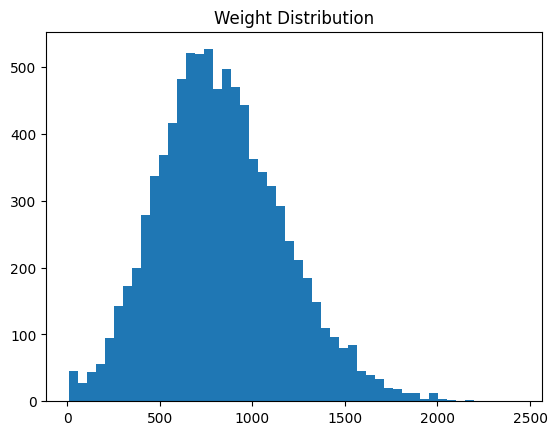

In [27]:
import matplotlib.pyplot as plt

plt.hist(df['Weight'], bins=50)
plt.title("Weight Distribution")
plt.show()

In [28]:
cargo.groupby('SHC')['Weight'].mean()


SHC
AOG    804.428219
COL    843.389180
EAW    832.119749
ECC    837.050524
ELM    838.760644
HEA    828.192257
RFL    813.860371
SPX    851.289832
Name: Weight, dtype: float64

In [29]:
cargo.groupby('origin')['Weight'].mean()

origin
AMS    827.000000
DXB    827.894840
FRA    832.623069
HAM    828.841693
JFK    820.234391
MAA    845.103557
MXP    817.830523
OSL    835.706442
PVG    843.582766
Name: Weight, dtype: float64

In [30]:
cargo.groupby('holiday_flag')['Weight'].mean()

holiday_flag
0    829.395913
1    837.194049
Name: Weight, dtype: float64

**5.3 Hypothesis Testing**


5.3.1 Hypothesis Testing for weather

In [31]:
bad_weather = cargo[cargo['origin_bad_weather_flag'] == 1]['Weight']
normal_weather = cargo[cargo['origin_bad_weather_flag'] == 0]['Weight']

# t-test
t_stat, p_value = ttest_ind(bad_weather, normal_weather, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 0.03794645480553916
P-value: 0.9697332168367354


5.3.1 Hypothesis Testing for holiday

In [32]:
holiday = cargo[cargo['holiday_flag'] == 1]['Weight']
non_holiday = cargo[cargo['holiday_flag'] == 0]['Weight']

t_stat, p_value = ttest_ind(holiday, non_holiday, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 0.870287452902641
P-value: 0.38421376952278735


**Hypothesis Testing Summary**

* We performed a t-test to compare cargo weight between different groups (bad vs normal weather, holiday vs non-holiday).
* Null hypothesis (H₀) assumes no significant difference in cargo weight between the groups.
* p-values are greater than 0.05, we fail to reject the null hypothesis.
* weather and holiday factors do not have a statistically significant impact on cargo weight in this dataset.


**5.4 Drop unwanted Columns**

In [33]:
columns_to_drop = [
    'MAWB Prefix',
    'MAWB Number',
    'Master Sequence',
    'HAWB Prefix',
    'HAWB Number',
    'House Sequence',
    'Consignee Name',
    'Flight Number',  
    
    
]

cargo = cargo.drop(columns=columns_to_drop, errors='ignore')

**5.5 Encoding categorical value**

In [34]:
from sklearn.preprocessing import LabelEncoder

le_shc = LabelEncoder()
le_origin = LabelEncoder()

le_shc.fit(cargo['SHC'])
le_origin.fit(cargo['origin'])

# THEN transform
cargo['SHC'] = le_shc.transform(cargo['SHC'])
cargo['origin'] = le_origin.transform(cargo['origin'])

In [35]:
cargo['Flight Date'] = pd.to_datetime(cargo['Flight Date'])
def add_date_features(df):
    df = df.copy()
    df["Month"]      = df["Flight Date"].dt.month
    df["Day"]        = df["Flight Date"].dt.day
    df["DayOfWeek"]  = df["Flight Date"].dt.dayofweek
    df["IsWeekend"]  = (df["DayOfWeek"] >= 5).astype(int)
    return df

cargo = add_date_features(cargo)

In [36]:
daily_df = cargo.groupby(['Flight Date','origin','SHC']).agg({
    'Weight': 'sum',
    'Pieces': 'sum',
    'ULD Number': 'count',
    'origin_temp': 'mean',
    'origin_rain': 'mean',
    'origin_wind_speed': 'mean',
    'origin_snowfall': 'mean',
    'dest_temp': 'mean',
    'dest_rain': 'mean',
    'dest_wind_speed': 'mean',
    'dest_snowfall': 'mean',
    'origin_high_wind_flag': 'max',
    'origin_heavy_rain_flag': 'max',
    'origin_snow_flag': 'max',
    'origin_bad_weather_flag': 'max',
    'dest_high_wind_flag': 'max',
    'dest_heavy_rain_flag': 'max',
    'dest_snow_flag': 'max',    
    'holiday_flag': 'max',
    'Month': 'first',
    'DayOfWeek': 'first',
    'IsWeekend': 'first'
}).reset_index()

daily_df.rename(columns={
    'Weight': 'Total_Weight',
    'Pieces': 'Total_Pieces',
    'ULD Number': 'ULD_Count'
}, inplace=True)

**5.5 Feature Selection**

In [37]:
FEATURES = [
    'origin','SHC',
    'origin_temp','origin_rain','origin_wind_speed','origin_snowfall',
    'dest_temp','dest_rain','dest_wind_speed','dest_snowfall',
    'origin_bad_weather_flag','holiday_flag',
    'Month','DayOfWeek','IsWeekend'
]

**5.6 Split data**

In [38]:
# sort by date
daily_df = daily_df.sort_values('Flight Date')

# split (time-based)
split = int(len(daily_df) * 0.8)

train_feat = daily_df.iloc[:split]
test_feat = daily_df.iloc[split:]

# features
X_train = train_feat[FEATURES]
X_test = test_feat[FEATURES]

# targets
y_train_uld = train_feat['ULD_Count']
y_test_uld = test_feat['ULD_Count']

y_train_pieces = train_feat['Total_Pieces']
y_test_pieces = test_feat['Total_Pieces']

y_train_weight = train_feat['Total_Weight']
y_test_weight = test_feat['Total_Weight']

**6.Model Training**

In [39]:
models_dict = {
    "Linear": LinearRegression(),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

In [40]:
TARGETS = {
    "ULD_Count": (y_train_uld, y_test_uld),
    "Total_Pieces": (y_train_pieces, y_test_pieces),
    "Total_Weight": (y_train_weight, y_test_weight)
}

In [41]:
all_models = {}

for model_name, model in models_dict.items():
    
    print(f"\nTraining {model_name}...")
    all_models[model_name] = {}

    for target, (y_tr, y_te) in TARGETS.items():
        
        m = model.__class__(**model.get_params())
        m.fit(X_train, y_tr)

        all_models[model_name][target] = m


Training Linear...

Training RandomForest...

Training XGBoost...


**7. Evalution Metrics**

**7.1 evaluation metrics for regression models**

In [42]:
results = {}

for model_name in all_models:
    
    print(f"\n===== {model_name} =====")
    results[model_name] = {}

    for target, (y_tr, y_te) in TARGETS.items():
        
        pred = all_models[model_name][target].predict(X_test)

        r2 = r2_score(y_te, pred)
        mae = mean_absolute_error(y_te, pred)
        mse = mean_squared_error(y_te, pred)

        results[model_name][target] = {
            "r2": r2,
            "mae": mae,
            "mse": mse
        }

        print(f"{target}")
        print("R2:", r2)
        print("MAE:", mae)
        print("MSE:", mse)


===== Linear =====
ULD_Count
R2: -0.017168044508222957
MAE: 0.7833639882935626
MSE: 1.0057575609541936
Total_Pieces
R2: -0.050196677235784914
MAE: 59.6705540293043
MSE: 6186.942461827958
Total_Weight
R2: -0.044978385017006905
MAE: 731.8972956745921
MSE: 935228.5221202181

===== RandomForest =====
ULD_Count
R2: -0.02880813201838528
MAE: 0.787030565304288
MSE: 1.017267071193649
Total_Pieces
R2: -0.018699618264395035
MAE: 60.10773388730328
MSE: 6001.38627430915
Total_Weight
R2: -0.012239977269360214
MAE: 734.9960013637451
MSE: 905928.4972264952

===== XGBoost =====
ULD_Count
R2: -0.07500600814819336
MAE: 0.8122640252113342
MSE: 1.0629467964172363
Total_Pieces
R2: -0.06934499740600586
MAE: 60.654727935791016
MSE: 6299.74951171875
Total_Weight
R2: -0.07442281210548662
MAE: 752.0520454894062
MSE: 961580.5198509534


In [43]:
metrics_table = []
for model_name, targets in results.items():
    for target, metrics in targets.items():
        metrics_table.append({
            "Model": model_name,
            "Target": target,
            "R2": metrics["r2"],
            "MAE": metrics["mae"],
            "MSE": metrics["mse"]
        })

metrics_df = pd.DataFrame(metrics_table)
display(metrics_df)

,Model,Target,R2,MAE,MSE
0,Linear,ULD_Count,-0.017168,0.783364,1.005758
1,Linear,Total_Pieces,-0.050197,59.670554,6186.942462
2,Linear,Total_Weight,-0.044978,731.897296,935228.522120
3,RandomForest,ULD_Count,-0.028808,0.787031,1.017267
4,RandomForest,Total_Pieces,-0.018700,60.107734,6001.386274
5,RandomForest,Total_Weight,-0.012240,734.996001,905928.497226
6,XGBoost,ULD_Count,-0.075006,0.812264,1.062947
7,XGBoost,Total_Pieces,-0.069345,60.654728,6299.749512
8,XGBoost,Total_Weight,-0.074423,752.052045,961580.519851


**7.2 Choose the best model through minimum MSE**

In [44]:
best_model_name = min(
    results,
    key=lambda x: (
        results[x]['ULD_Count']['mse'] +
        results[x]['Total_Pieces']['mse'] +
        results[x]['Total_Weight']['mse']
    )
)

print("\nBest Model (Overall MSE):", best_model_name)


Best Model (Overall MSE): RandomForest


**8. Prediction Result part**

In [45]:
# def get_user_input():
    
#     date = input("Enter Flight Date (YYYY-MM-DD): ")
#     origin = input("Enter Origin (e.g., MAA, AMS, DXB, OSL): ")
#     shc = input("Enter SHC (e.g., RFL, SPX, AOG, ECC): ")

#     origin_temp = float(input("Enter Origin Temperature: "))
#     origin_rain = float(input("Enter Origin Rain: "))
#     origin_wind_speed = float(input("Enter Origin Wind Speed: "))
#     origin_snowfall = float(input("Enter Origin Snowfall: "))

#     dest_temp = float(input("Enter Destination Temperature: "))
#     dest_rain = float(input("Enter Destination Rain: "))
#     dest_wind_speed = float(input("Enter Destination Wind Speed: "))
#     dest_snowfall = float(input("Enter Destination Snowfall: "))

#     holiday_flag = int(input("Holiday? (0/1): "))

#     # weather flag (same logic)
#     origin_bad_weather_flag = int(
#         (origin_wind_speed > 30) or 
#         (origin_rain > 15) or 
#         (origin_snowfall > 0)
#     )

#     # date features
#     dt = pd.to_datetime(date)
#     month = dt.month
#     dayofweek = dt.dayofweek
#     is_weekend = int(dayofweek >= 5)

#     data = {
#         "Flight Date": dt,
#         "origin": origin,
#         "SHC": shc,

#         "origin_temp": origin_temp,
#         "origin_rain": origin_rain,
#         "origin_wind_speed": origin_wind_speed,
#         "origin_snowfall": origin_snowfall,

#         "dest_temp": dest_temp,
#         "dest_rain": dest_rain,
#         "dest_wind_speed": dest_wind_speed,
#         "dest_snowfall": dest_snowfall,

#         "origin_bad_weather_flag": origin_bad_weather_flag,
#         "holiday_flag": holiday_flag,

#         "Month": month,
#         "DayOfWeek": dayofweek,
#         "IsWeekend": is_weekend
#     }

#     return pd.DataFrame([data])

# # -----------------------------
# # FINAL FEATURES (MUST MATCH TRAINING)
# # -----------------------------
# FEATURES = [
#     'origin','SHC',
#     'origin_temp','origin_rain','origin_wind_speed','origin_snowfall',
#     'dest_temp','dest_rain','dest_wind_speed','dest_snowfall',
#     'origin_bad_weather_flag',
#     'holiday_flag',
#     'Month','DayOfWeek','IsWeekend'
#  ]


# origin_map = dict(zip(le_origin.classes_, le_origin.transform(le_origin.classes_)))
# shc_map = dict(zip(le_shc.classes_, le_shc.transform(le_shc.classes_)))

# # -----------------------------
# # PREDICTION FUNCTION
# # -----------------------------
# def predict_from_input(df_input, model_name):
#     # SAFE encoding (NO overwrite issue)
#     df_input['origin'] = df_input['origin'].map(origin_map).fillna(0)
#     df_input['SHC'] = df_input['SHC'].map(shc_map).fillna(0)
#     # Ensure all required features exist
#     for col in FEATURES:
#         if col not in df_input.columns:
#             df_input[col] = 0
#     X_input = df_input[FEATURES].copy()
#     X_input = X_input.fillna(0)
    
#     # prediction
#     model_set = all_models[model_name]
#     uld_pred = model_set['ULD_Count'].predict(X_input)[0]
#     pieces_pred = model_set['Total_Pieces'].predict(X_input)[0]
#     weight_pred = model_set['Total_Weight'].predict(X_input)[0]
#     return {
#         "ULD_Count": int(round(uld_pred)),
#         "Total_Pieces": int(round(pieces_pred)),
#         "Total_Weight": float(round(weight_pred, 2))
#     }

# # -----------------------------
# # RUN
# # -----------------------------
# user_df = get_user_input()
# result = predict_from_input(user_df, best_model_name)

# print("\n===== PREDICTION RESULT =====")
# print(f"Model Used: {best_model_name}")
# print(f"ULD Count: {result['ULD_Count']}")
# print(f"Total Pieces: {result['Total_Pieces']}")
# print(f"Total Weight: {result['Total_Weight']}")

In [48]:
import joblib

joblib.dump(all_models, "model.pkl")
joblib.dump(best_model_name, "best_model.pkl")

['best_model.pkl']

In [47]:
# import streamlit as st
# import pandas as pd
# import joblib


# # Load model properly
# model_data = joblib.load("model.pkl")

# st.write(model_data.keys())


# uld_model = model_data["ULD_count"]
# weight_model = model_data["Total_weight"]
# pieces_model = model_data["Total_pieces"]

# st.title("✈️ Flight Weight Prediction App")

# # Inputs
# date = st.date_input("Flight Date")

# origin = st.selectbox("Origin", ["MAA", "AMS", "DXB", "OSL", "FRA", "LHR", "CDG", "JFK"])
# shc = st.selectbox("SHC", ["COL","RFL","ELM","EAW","AOG","HEA","SPX","ECC"])

# origin_temp = st.number_input("Origin Temperature")
# origin_rain = st.number_input("Origin Rainfall")
# origin_Windspeed = st.number_input("Origin Wind Speed")
# origin_snowfall = st.number_input("Origin Snowfall")

# dest_temp = st.number_input("Destination Temperature")
# dest_rain = st.number_input("Destination Rainfall")
# dest_Windspeed = st.number_input("Destination Wind Speed")
# dest_snowfall = st.number_input("Destination Snowfall")

# # DataFrame
# input_data = pd.DataFrame({
#     "date": [str(date)],
#     "origin": [origin],
#     "shc": [shc],
#     "origin_temp": [origin_temp],
#     "origin_rain": [origin_rain],
#     "origin_Windspeed": [origin_Windspeed],
#     "origin_snowfall": [origin_snowfall],
#     "dest_temp": [dest_temp],
#     "dest_rain": [dest_rain],
#     "dest_Windspeed": [dest_Windspeed],
#     "dest_snowfall": [dest_snowfall]
# })

# # Predict
# if st.button("Predict"):
#     uld_pred = uld_model.predict(input_data)
#     weight_pred = weight_model.predict(input_data)
#     pieces_pred = pieces_model.predict(input_data)

#     st.success(f"Predicted ULD: {uld_pred[0]}")
#     st.success(f"Predicted Weight: {weight_pred[0]}")
#     st.success(f"Predicted Pieces: {pieces_pred[0]}")